# Challenge 2: Kernel Methods for Classification and Dimensionality Reduction

The challenge is to explore when kernelised methods outperform their linear counterparts on two toy datasets, and determine which kernel is most suitable for each.

**Tasks:**
1. Linear SVM vs Kernel SVM (classification)
2. PCA vs Kernel PCA (on `make_moons`)
3. PCA vs Kernel PCA (on `make_blobs` with linear transform)

In [1]:
# Imports used throughout the notebook
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA, KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

---
## Part 1 — Linear SVM vs Kernel SVM

Using the training and test datasets below, you have to:

- Fit a **linear SVM** classifier;
- Fit a **Kernel SVM** with an **RBF kernel** and one with a **Polynomial kernel**. Through a grid search, explore how different values of `gamma` and `C` for the RBF kernel, and different `degree` and `C` values for the Polynomial kernel, affect the decision boundary;
- Finally, fit one last SVM with the **best kernel and parameters** that maximise the test accuracy.

For each subtask, report the **test accuracy** and plot the **decision boundary** against the data points.

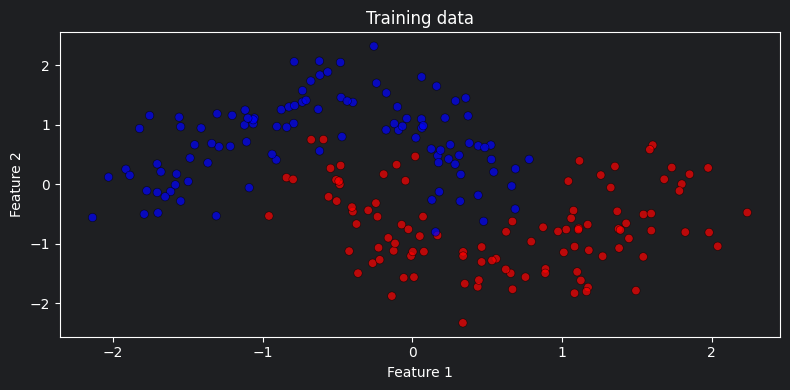

In [60]:
# ── Dataset creation ──────────────────────────────────────────────────────────
# A two-class dataset that is NOT linearly separable,
# so a linear SVM will visibly struggle.
np.random.seed(42)

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Scale features before fitting an SVM
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Quick plot of the training data
plt.figure(figsize=(8, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
            cmap='bwr', alpha=0.7, edgecolors='k', linewidths=0.4)
plt.title('Training data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

# ── Helper: plot decision boundary ───────────────────────────────────────────
def plot_decision_boundary(clf, X, y, title='Decision boundary'):
    """Plot the decision boundary of a fitted classifier."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr',
                edgecolors='k', linewidths=0.4)
    plt.title(title)
    plt.tight_layout()
    plt.show()

### 1a — Linear SVM

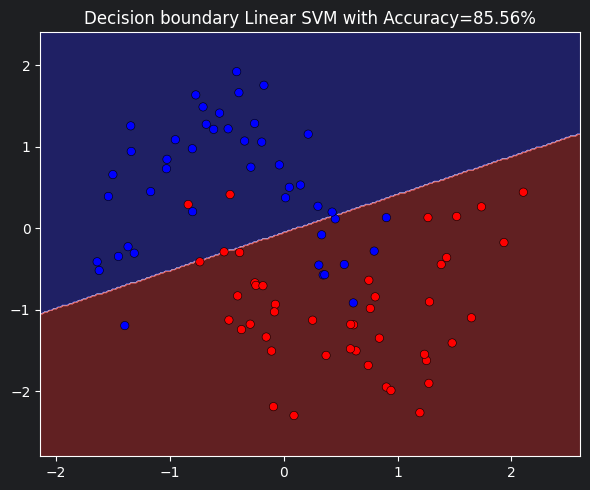

In [61]:
# TODO: Fit a linear SVM (SVC with kernel='linear').
# Report the test accuracy and plot the decision boundary
# using plot_decision_boundary().

clf = SVC(kernel='linear')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)*100

plot_decision_boundary(clf, X_test, y_test, title=f'Decision boundary Linear SVM with Accuracy={acc:.2f}%')

### 1b — Kernel SVM with RBF kernel (grid search over `gamma` and `C`)

In [4]:
# TODO: Try different combinations of gamma and C for the RBF kernel.
# For each combination, fit an SVC, report the test accuracy,
# and plot the decision boundary.



param_grid = {'C': [0.1, 1.0, 10.0, 100.0],
        'gamma': [0.1, 0.5, 1.0, 5.0],
        'kernel': ['rbf']
        }

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.881 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.881 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.833 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.881 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.857 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.5, kernel=rbf;, score=0.929 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.5, kernel=rbf;, score=0.905 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.5, kernel=rbf;, score=0.857 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.5, kernel=rbf;, score=0.952 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.5, kernel=rbf;, score=0.857 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=1.0, kernel=rbf;, score=0.929 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=1.0, kernel=rbf;

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1.0, ...], 'gamma': [0.1, 0.5, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold a

In [5]:
grid_pred = grid.predict(X_test)
print(classification_report(y_test, grid_pred))

              precision    recall  f1-score   support

           0       1.00      0.84      0.92        45
           1       0.87      1.00      0.93        45

    accuracy                           0.92        90
   macro avg       0.93      0.92      0.92        90
weighted avg       0.93      0.92      0.92        90



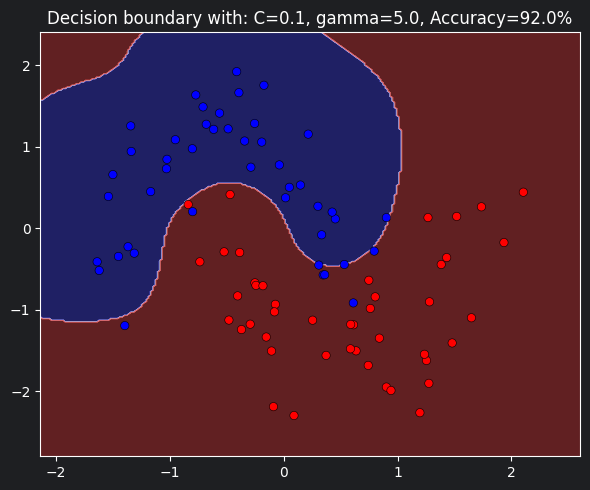

In [6]:
best_C, best_gamma, kern = grid.best_params_.values()
best_estimator = grid.best_estimator_
plot_decision_boundary(best_estimator, X_test, y_test, title=f'Decision boundary with: C={best_C}, gamma={best_gamma}, Accuracy=92.0%')

### 1c — Kernel SVM with Polynomial kernel (grid search over `degree` and `C`)

In [7]:
# TODO: Try different combinations of degree and C for the Polynomial kernel.
# For each combination, fit an SVC, report the test accuracy,
# and plot the decision boundary.

param_grid_poly = {'C': [0.1, 1.0, 10.0, 100.0],
                   'gamma': [0.1, 0.5, 1.0, 5.0],
        'degree': [2, 3, 4, 5],
        'kernel': ['poly']
        }

grid_poly = GridSearchCV(SVC(), param_grid_poly, refit=True, verbose=3)

grid_poly.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END C=0.1, degree=2, gamma=0.1, kernel=poly;, score=0.452 total time=   0.0s
[CV 2/5] END C=0.1, degree=2, gamma=0.1, kernel=poly;, score=0.595 total time=   0.0s
[CV 3/5] END C=0.1, degree=2, gamma=0.1, kernel=poly;, score=0.452 total time=   0.0s
[CV 4/5] END C=0.1, degree=2, gamma=0.1, kernel=poly;, score=0.595 total time=   0.0s
[CV 5/5] END C=0.1, degree=2, gamma=0.1, kernel=poly;, score=0.405 total time=   0.0s
[CV 1/5] END C=0.1, degree=2, gamma=0.5, kernel=poly;, score=0.452 total time=   0.0s
[CV 2/5] END C=0.1, degree=2, gamma=0.5, kernel=poly;, score=0.595 total time=   0.0s
[CV 3/5] END C=0.1, degree=2, gamma=0.5, kernel=poly;, score=0.476 total time=   0.0s
[CV 4/5] END C=0.1, degree=2, gamma=0.5, kernel=poly;, score=0.595 total time=   0.0s
[CV 5/5] END C=0.1, degree=2, gamma=0.5, kernel=poly;, score=0.476 total time=   0.0s
[CV 1/5] END C=0.1, degree=2, gamma=1.0, kernel=poly;, score=0.381 total time=

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1.0, ...], 'degree': [2, 3, ...], 'gamma': [0.1, 0.5, ...], 'kernel': ['poly']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

In [8]:
grid_poly_pred = grid_poly.predict(X_test)
print(classification_report(y_test, grid_poly_pred))

              precision    recall  f1-score   support

           0       0.94      0.69      0.79        45
           1       0.75      0.96      0.84        45

    accuracy                           0.82        90
   macro avg       0.85      0.82      0.82        90
weighted avg       0.85      0.82      0.82        90



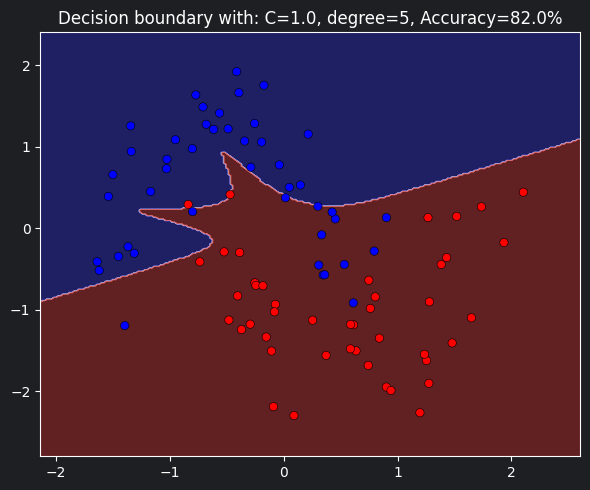

In [9]:
best_C_pol, best_deg,gamma, kern = grid_poly.best_params_.values()
best_estimator_pol = grid_poly.best_estimator_
plot_decision_boundary(best_estimator_pol, X_test, y_test, title=f'Decision boundary with: C={best_C_pol}, degree={best_deg}, Accuracy=82.0%')

### 1d — Best model

Based on the grid search results above, identify the kernel and hyperparameter combination that maximises the test accuracy, fit the final model, and produce a clean decision boundary plot.

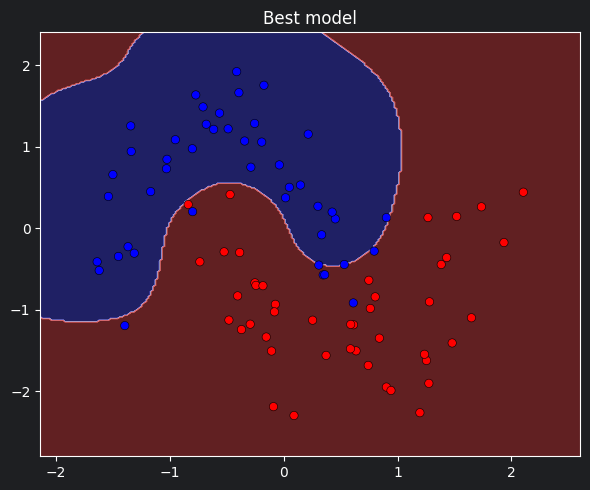

In [10]:
# TODO: Fit the best SVM model and plot the final decision boundary.
# Report the test accuracy and print the full classification report.


best_rbf = SVC(**grid.best_params_)
best_rbf.fit(X_train, y_train)
acc_rbf = accuracy_score(y_test, best_rbf.predict(X_test))

best_poly = SVC(**grid_poly.best_params_)
best_poly.fit(X_train, y_train)
acc_poly = accuracy_score(y_test, best_poly.predict(X_test))


best_model = best_rbf if acc_rbf >= acc_poly else best_poly
plot_decision_boundary(best_model, X_test, y_test, title='Best model')

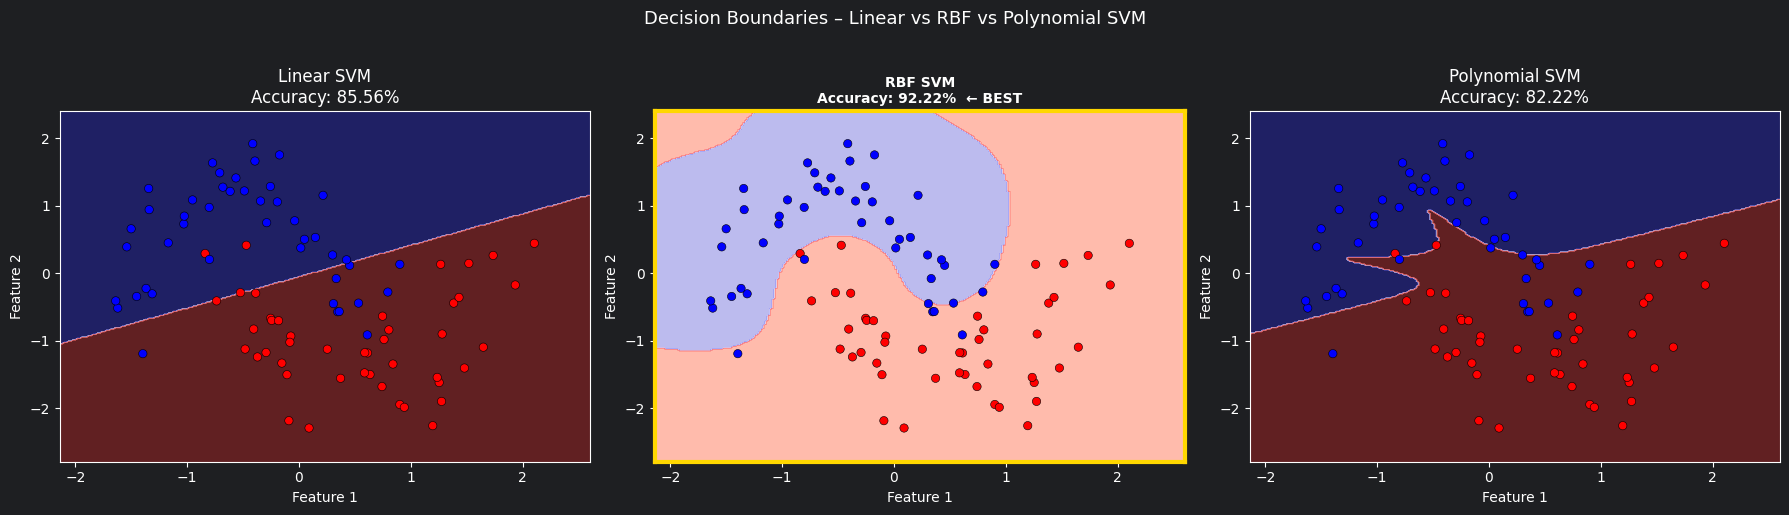

In [64]:
#-----------------------------------------
# Plotting all the graphs
#-----------------------------------------

models = [
    (clf,       "Linear SVM"),
    (best_rbf,  "RBF SVM"),
    (best_poly, "Polynomial SVM")
]

BEST = "RBF SVM"

h = 0.02
x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model, title) in zip(axes, models):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="bwr")
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="bwr",
               edgecolors="k", linewidths=0.4)


    if title == BEST:
        ax.set_title(f"{title}\nAccuracy: {acc*100:.2f}%  ← BEST",
                     fontsize=10, fontweight='bold')
        for spine in ax.spines.values():
            spine.set_edgecolor('gold')
            spine.set_linewidth(3)
        ax.set_facecolor('#fffde7')
    else:
        ax.set_title(f"{title}\nAccuracy: {acc*100:.2f}%")


    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.suptitle("Decision Boundaries – Linear vs RBF vs Polynomial SVM",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [65]:
# ----------------------------------------
# Classification Report for the 3 models
# ----------------------------------------
from sklearn.metrics import classification_report

model_names = ["Linear SVM", "RBF SVM", "Polynomial SVM"]
model_list  = [clf, best_rbf, best_poly]

for name, model in zip(model_names, model_list):
    y_pred = model.predict(X_test)
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))

  Linear SVM
              precision    recall  f1-score   support

           0       0.92      0.78      0.84        45
           1       0.81      0.93      0.87        45

    accuracy                           0.86        90
   macro avg       0.86      0.86      0.85        90
weighted avg       0.86      0.86      0.85        90

  RBF SVM
              precision    recall  f1-score   support

           0       1.00      0.84      0.92        45
           1       0.87      1.00      0.93        45

    accuracy                           0.92        90
   macro avg       0.93      0.92      0.92        90
weighted avg       0.93      0.92      0.92        90

  Polynomial SVM
              precision    recall  f1-score   support

           0       0.94      0.69      0.79        45
           1       0.75      0.96      0.84        45

    accuracy                           0.82        90
   macro avg       0.85      0.82      0.82        90
weighted avg       0.85      0.82 

---
## Part 2 — PCA vs Kernel PCA on `make_moons`

Using the dataset below, you have to:

- Fit a **PCA** model and project the data;
- Fit a **Kernel PCA** model with a kernel of your choice and project the data.

For each subtask, **plot the projected data** (coloured by class label) and **evaluate the quality of the projection** by training a Logistic Regression classifier on the projected training set and measuring accuracy on the projected test set.

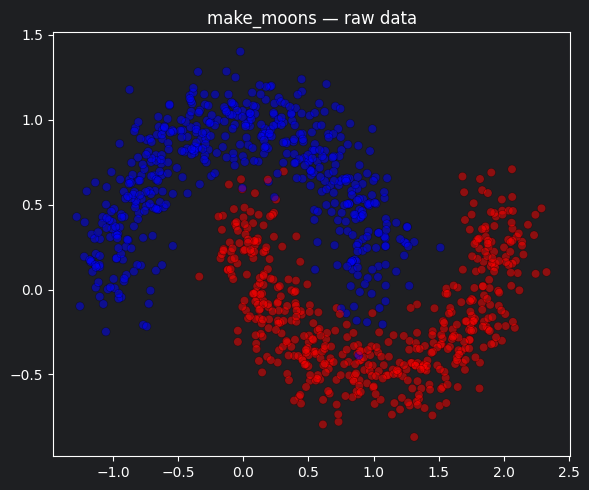

In [66]:
# ── Dataset creation ──────────────────────────────────────────────────────────
X, y = make_moons(n_samples=1000, noise=0.15, random_state=0)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y, stratify=y, random_state=0
)

# Quick plot of the raw data
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.5, edgecolors='k', linewidths=0.3)
plt.title('make_moons — raw data')
plt.tight_layout()
plt.show()

### 2a — Linear PCA

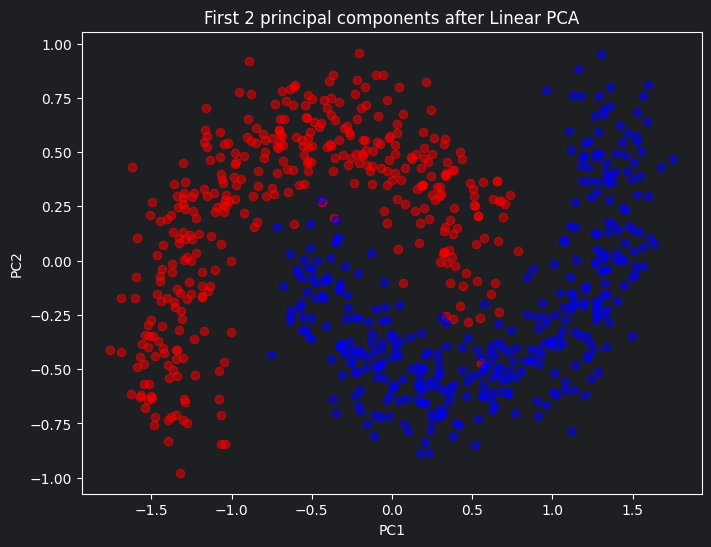

In [67]:
# TODO: Fit PCA (n_components=2), project train and test sets.
# Plot the projected training data coloured by class label.

# ── Logistic Regression evaluation snippet ────────────────────────────────────

pca = PCA(n_components=2)
X_train_proj = pca.fit_transform(X_train_m)
X_test_proj = pca.transform(X_test_m)

plt.figure(figsize=(8,6))
plt.scatter(X_train_proj[y_train_m==0, 0], X_train_proj[y_train_m==0, 1], color='red', alpha=0.5)
plt.scatter(X_train_proj[y_train_m==1, 0], X_train_proj[y_train_m==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after Linear PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [68]:
clf = LogisticRegression()
clf.fit(X_train_proj, y_train_m)

y_pred = clf.predict(X_test_proj)
print(f"Test accuracy: {accuracy_score(y_test_m, y_pred)*100:.2f}%")

Test accuracy: 87.20%


### 2b — Kernel PCA

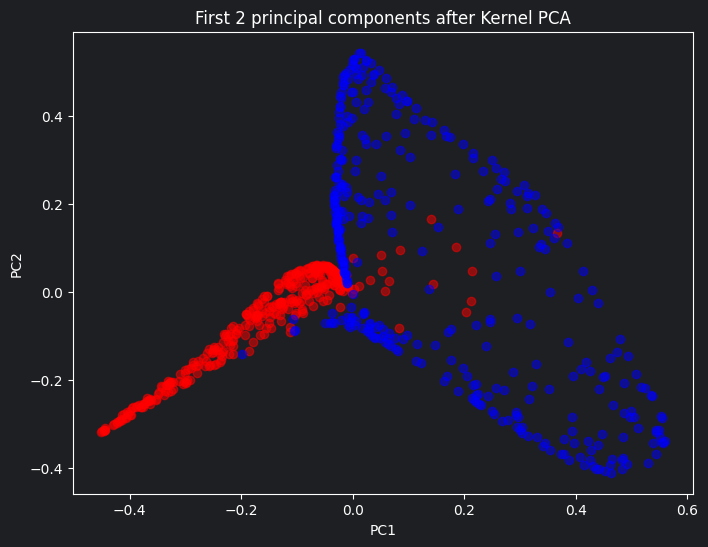

In [69]:
# TODO: Fit KernelPCA (n_components=2) with a kernel of your choice.
# Project train and test sets, plot the projections, and evaluate with Logistic Regression.
#
# Hint: try kernel='rbf' and experiment with the gamma parameter.
# Remember to use fit_transform on train and transform on test.

# ── Logistic Regression evaluation snippet ────────────────────────────────────
# Replace `decomp` with your fitted KernelPCA instance.


kpca = KernelPCA(n_components=2, kernel='rbf', gamma=16)
X_train_proj = kpca.fit_transform(X_train_m)
X_test_proj  = kpca.transform(X_test_m)

plt.figure(figsize=(8,6))
plt.scatter(X_train_proj[y_train_m==0, 0], X_train_proj[y_train_m==0, 1], color='red', alpha=0.5)
plt.scatter(X_train_proj[y_train_m==1, 0], X_train_proj[y_train_m==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after Kernel PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [70]:
clf = LogisticRegression()
clf.fit(X_train_proj, y_train_m)

y_pred = clf.predict(X_test_proj)
print(f"Test accuracy: {accuracy_score(y_test_m, y_pred)*100:.2f}%")

Test accuracy: 91.60%


In [71]:
# Make Pipeline
# The pipeline will concatenate the steps: first it applies PCA, then it will pass the results to Logistic
pipeline = Pipeline([
    ('kpca', KernelPCA(n_components=2)),
    ('clf', LogisticRegression())
])

# Define param grid
param_grid = [
    {
        'kpca__kernel': ['cosine']
    },
        {
        'kpca__kernel': ['sigmoid'],
        'kpca__gamma': [0.01, 0.1, 1.0],
        'kpca__coef0': [0.0, 1.0]
    },
        {
        'kpca__kernel': ['poly'],
        'kpca__degree': [2, 3, 4],
        'kpca__gamma': [0.1, 1.0],
        'kpca__coef0': [0.0, 1.0]
    }
]

# Starting Grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_m, y_train_m)

print("Best params:")
print(grid_search.best_params_)
print(f"Best accuracy in validation (CV): {grid_search.best_score_ * 100:.2f}%")


y_pred_m = grid_search.predict(X_test_m)
print(f"Accuracy on Test Set: {accuracy_score(y_test_m, y_pred_m) * 100:.2f}%")

Best params:
{'kpca__coef0': 1.0, 'kpca__degree': 2, 'kpca__gamma': 1.0, 'kpca__kernel': 'poly'}
Best accuracy in validation (CV): 87.47%
Accuracy on Test Set: 86.80%


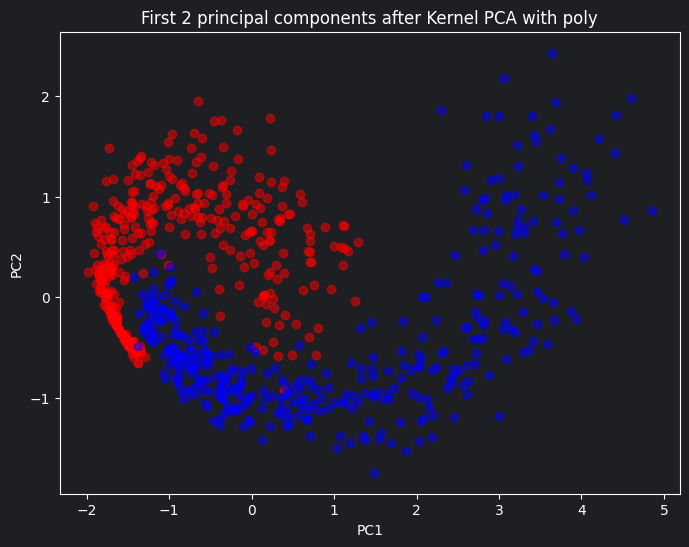

In [72]:
polympca = KernelPCA(n_components=2, kernel='poly', coef0=1.0, degree=2, gamma=1.0)
X_train_polim = polympca.fit_transform(X_train_m)
X_test_polim  = polympca.transform(X_test_m)

plt.figure(figsize=(8,6))
plt.scatter(X_train_polim[y_train_m==0, 0], X_train_polim[y_train_m==0, 1], color='red', alpha=0.5)
plt.scatter(X_train_polim[y_train_m==1, 0], X_train_polim[y_train_m==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after Kernel PCA with poly')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

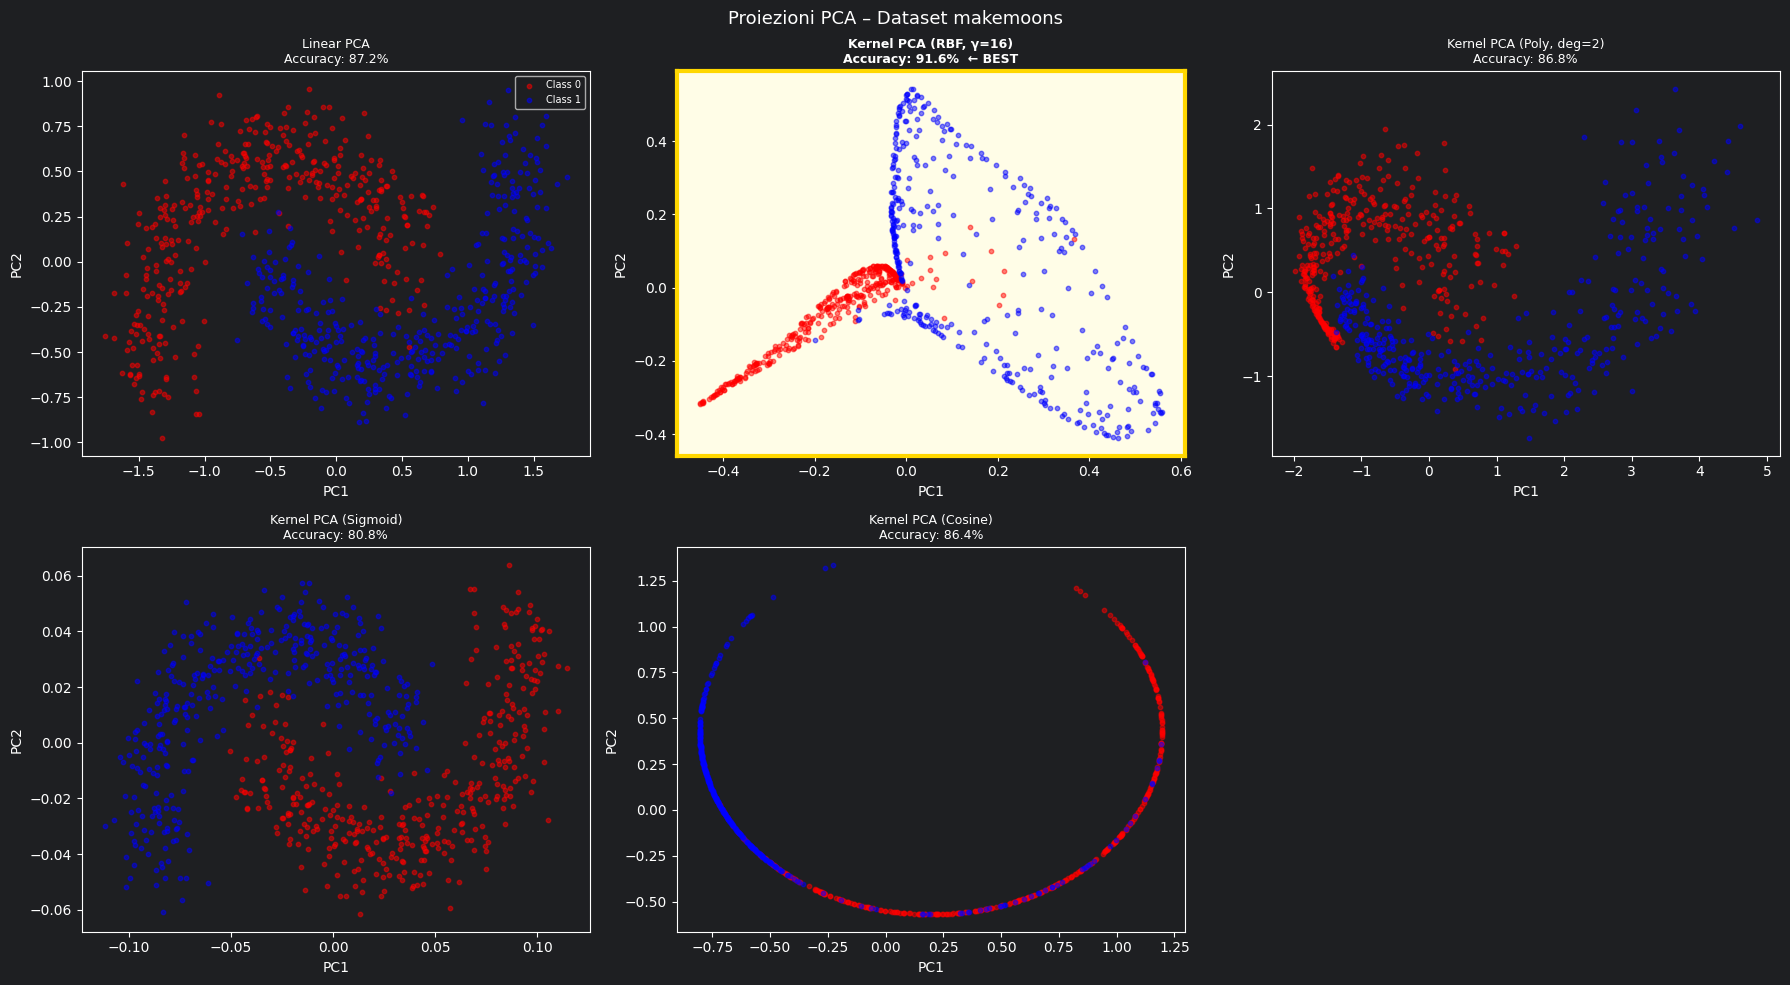

In [74]:
# -------------------------------------
# Plot all PCA projections – makemoons
# -------------------------------------

# Recompute all projections (using best params)
pca_configs = [
    ("Linear PCA",       PCA(n_components=2)),
    ("Kernel PCA (RBF, γ=16)",    KernelPCA(n_components=2, kernel='rbf',     gamma=16)),
    ("Kernel PCA (Poly, deg=2)",  KernelPCA(n_components=2, kernel='poly',    gamma=1.0, coef0=1.0, degree=2)),
    ("Kernel PCA (Sigmoid)",      KernelPCA(n_components=2, kernel='sigmoid', gamma=0.01, coef0=1.0)),
    ("Kernel PCA (Cosine)",       KernelPCA(n_components=2, kernel='cosine')),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
axes_flat[-1].set_visible(False)

BEST = "Kernel PCA (RBF, γ=16)"

for ax, (name, decomp) in zip(axes_flat, pca_configs):
    Xtr_proj = decomp.fit_transform(X_train_m)
    Xte_proj = decomp.transform(X_test_m)
    lr = LogisticRegression(max_iter=1000)
    lr.fit(Xtr_proj, y_train_m)
    acc = accuracy_score(y_test_m, lr.predict(Xte_proj)) * 100

    for cls in [0, 1]:
        mask = y_train_m == cls
        ax.scatter(Xtr_proj[mask, 0], Xtr_proj[mask, 1],
                   color=colors[cls], alpha=0.5, s=10, label=f"Class {cls}")


    if name == BEST:
        ax.set_title(f"{name}\nAccuracy: {acc:.1f}%  ← BEST", fontsize=9,
                     fontweight='bold')
        for spine in ax.spines.values():
            spine.set_edgecolor('gold')
            spine.set_linewidth(3)
        ax.set_facecolor('#fffde7')
    else:
        ax.set_title(f"{name}\nAccuracy: {acc:.1f}%", fontsize=9)


    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

axes_flat[0].legend(fontsize=7)
plt.suptitle("Proiezioni PCA – Dataset makemoons", fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 3 — PCA vs Kernel PCA on `make_blobs` (with linear transform)

Repeat the previous task using a dataset generated with `make_blobs`, configured to produce **overlapping, non-spherical clusters** by applying a random linear transformation to the data.

Find the best kernel and comment on your findings:
- What differences do you observe compared to the `make_moons` dataset?
- Does Kernel PCA offer any advantage here, and why?
- Motivate why you choose one kernel w.r.t. another

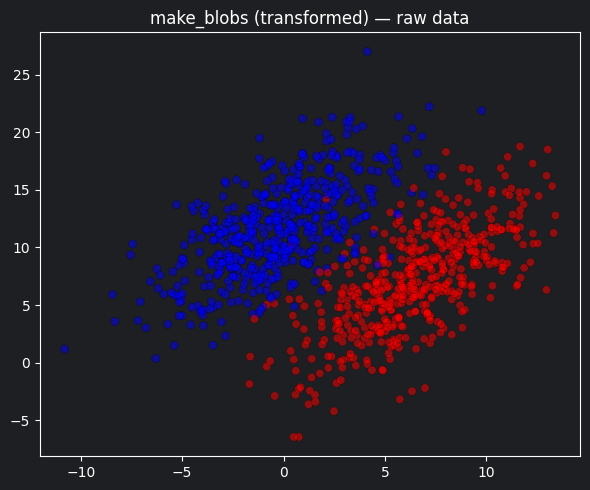

In [87]:
# ── Dataset creation ──────────────────────────────────────────────────────────
np.random.seed(42)
X_b, y_b = make_blobs(n_samples=1000, centers=2, cluster_std=2.5, random_state=42)

# Apply a linear transformation to make clusters non-spherical
transform = np.array([[1.2, 0.8],
                      [0.3, 1.5]])
X_b = X_b @ transform

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b, stratify=y_b, random_state=0
)

# Quick plot
plt.figure(figsize=(6, 5))
plt.scatter(X_b[:, 0], X_b[:, 1], c=y_b, cmap='bwr', alpha=0.5, edgecolors='k', linewidths=0.3)
plt.title('make_blobs (transformed) — raw data')
plt.tight_layout()
plt.show()

### 3a — Linear PCA

In [88]:
# TODO: Fit PCA on the blobs dataset, plot the projections,
# and evaluate with Logistic Regression (same snippet as Part 2).

# TODO: Try different kernels (e.g. 'rbf', 'poly', 'sigmoid', 'cosine') on the blobs dataset.
# For each, plot the projections and report the Logistic Regression accuracy.
# Identify the best kernel and justify your choice.

# Make Pipeline
# The pipeline will concat the steps: first it apply PCA, then it will pass the results to Logistic
pipeline = Pipeline([
    ('kpca', KernelPCA(n_components=2)),
    ('clf', LogisticRegression())
])

# Define param grid
param_grid = [
    {
        'kpca__kernel': ['linear']}
]

# Starting Grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_b, y_train_b)

print("Best params:")
print(grid_search.best_params_)
print(f"Best accuracy in validation (CV): {grid_search.best_score_ * 100:.2f}%")


y_pred_b = grid_search.predict(X_test_b)
print(f"Accuracy on Test Set: {accuracy_score(y_test_b, y_pred_b) * 100:.2f}%")

Best params:
{'kpca__kernel': 'linear'}
Best accuracy in validation (CV): 96.80%
Accuracy on Test Set: 98.80%


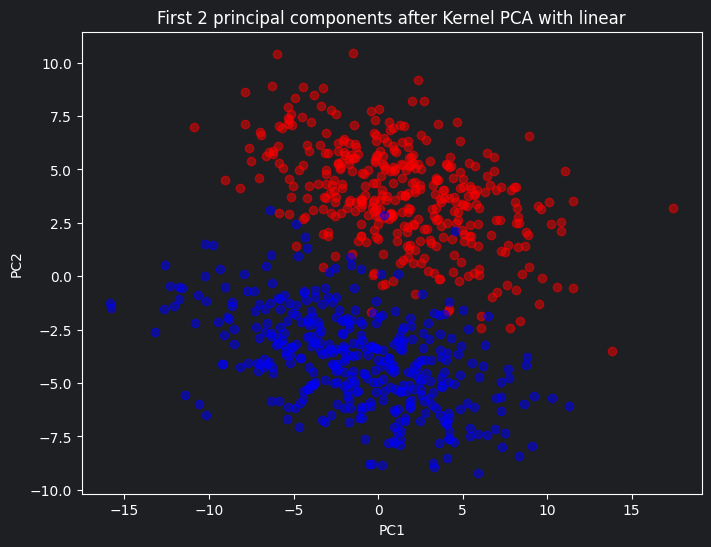

In [89]:
pca = KernelPCA(n_components=2, kernel='linear')
X_train = pca.fit_transform(X_train_b)
X_test  = pca.transform(X_test_b)

plt.figure(figsize=(8,6))
plt.scatter(X_train[y_train_b==0, 0], X_train[y_train_b==0, 1], color='red', alpha=0.5)
plt.scatter(X_train[y_train_b==1, 0], X_train[y_train_b==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after Kernel PCA with linear')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### 3b — Kernel PCA (find the best kernel)

In [90]:
# TODO: Try different kernels (e.g. 'rbf', 'poly', 'sigmoid', 'cosine') on the blobs dataset.
# For each, plot the projections and report the Logistic Regression accuracy.
# Identify the best kernel and justify your choice.

# Make Pipeline
# The pipeline will concatenate the steps: first it applies PCA, then it will pass the results to Logistic
pipeline = Pipeline([
    ('kpca', KernelPCA(n_components=2)),
    ('clf', LogisticRegression())
])

# Define param grid
param_grid = [
    {
        'kpca__kernel': ['sigmoid'],
        'kpca__gamma': [0.01, 0.1, 1.0],
        'kpca__coef0': [0.0, 1.0]
    }
]

# Starting Grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_b, y_train_b)

print("Best params:")
print(grid_search.best_params_)
print(f"Best accuracy in validation (CV): {grid_search.best_score_ * 100:.2f}%")


y_pred_b = grid_search.predict(X_test_b)
print(f"Accuracy on Test Set: {accuracy_score(y_test_b, y_pred_b) * 100:.2f}%")

Best params:
{'kpca__coef0': 1.0, 'kpca__gamma': 0.01, 'kpca__kernel': 'sigmoid'}
Best accuracy in validation (CV): 97.07%
Accuracy on Test Set: 97.60%


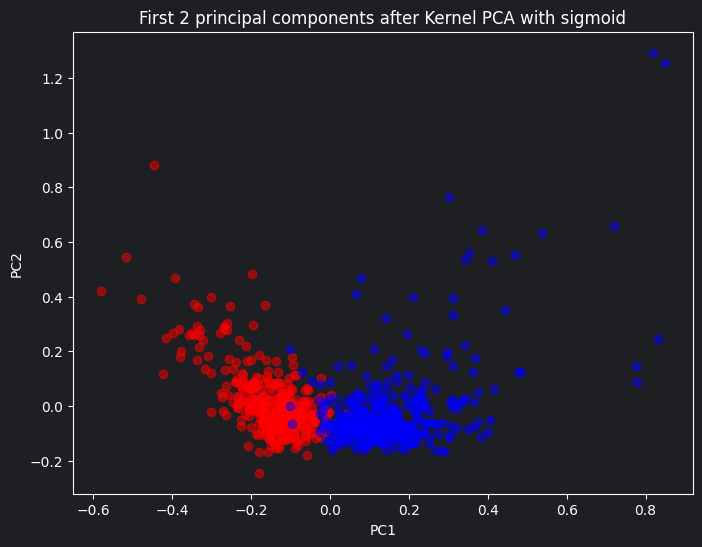

In [91]:
sigpca = KernelPCA(n_components=2, kernel='sigmoid', gamma=0.01, coef0= 1.0)
X_train_sig = sigpca.fit_transform(X_train_b)
X_test_sig  = sigpca.transform(X_test_b)

plt.figure(figsize=(8,6))
plt.scatter(X_train_sig[y_train_b==0, 0], X_train_sig[y_train_b==0, 1], color='red', alpha=0.5)
plt.scatter(X_train_sig[y_train_b==1, 0], X_train_sig[y_train_b==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after Kernel PCA with sigmoid')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [92]:
pipeline = Pipeline([
    ('kpca', KernelPCA(n_components=2)),
    ('clf', LogisticRegression())
])

# Define param grid
param_grid = [
    {
        'kpca__kernel': ['cosine']
    }
]

# Starting Grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_b, y_train_b)

print("Best params:")
print(grid_search.best_params_)
print(f"Best accuracy in validation (CV): {grid_search.best_score_ * 100:.2f}%")


y_pred_b = grid_search.predict(X_test_b)
print(f"Accuracy on Test Set: {accuracy_score(y_test_b, y_pred_b) * 100:.2f}%")

Best params:
{'kpca__kernel': 'cosine'}
Best accuracy in validation (CV): 96.40%
Accuracy on Test Set: 96.80%


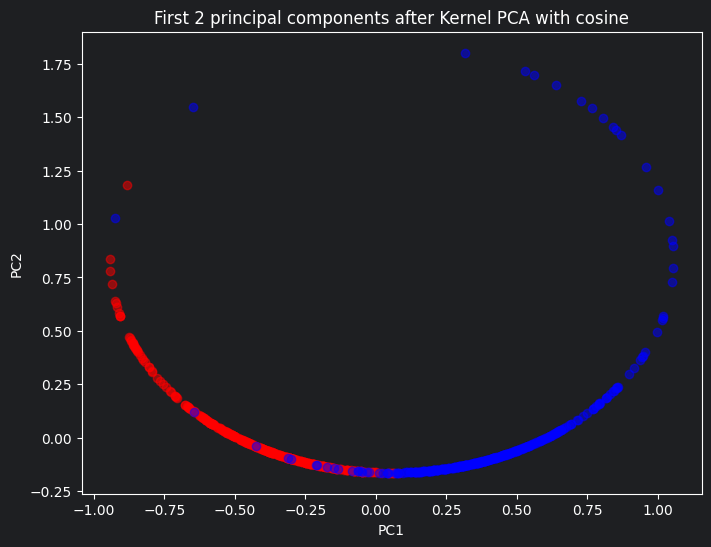

In [93]:
cosnpca = KernelPCA(n_components=2, kernel='cosine')
X_train_cos = cosnpca.fit_transform(X_train_b)
X_test_cos  = cosnpca.transform(X_test_b)

plt.figure(figsize=(8,6))
plt.scatter(X_train_cos[y_train_b==0, 0], X_train_cos[y_train_b==0, 1], color='red', alpha=0.5)
plt.scatter(X_train_cos[y_train_b==1, 0], X_train_cos[y_train_b==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after Kernel PCA with cosine')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [94]:
pipeline = Pipeline([
    ('kpca', KernelPCA(n_components=2)),
    ('clf', LogisticRegression())
])

# Define param grid
param_grid = [
    {
        'kpca__kernel': ['poly'],
        'kpca__degree': [2, 3, 4],
        'kpca__gamma': [0.1, 1.0],
        'kpca__coef0': [0.0, 1.0]
    }
]

# Starting Grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_b, y_train_b)

print("Best params:")
print(grid_search.best_params_)
print(f"Best accuracy in validation (CV): {grid_search.best_score_ * 100:.2f}%")


y_pred_b = grid_search.predict(X_test_b)
print(f"Accuracy on Test Set: {accuracy_score(y_test_b, y_pred_b) * 100:.2f}%")

Best params:
{'kpca__coef0': 1.0, 'kpca__degree': 2, 'kpca__gamma': 0.1, 'kpca__kernel': 'poly'}
Best accuracy in validation (CV): 96.27%
Accuracy on Test Set: 97.60%


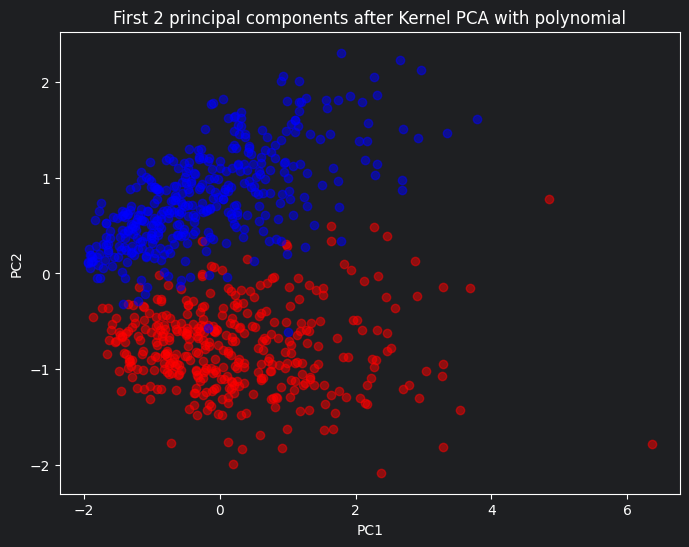

In [95]:
polpca = KernelPCA(n_components=2, kernel='poly', gamma=0.01, coef0= 1.0, degree=2)
X_train_pol = polpca.fit_transform(X_train_b)
X_test_pol  = polpca.transform(X_test_b)

plt.figure(figsize=(8,6))
plt.scatter(X_train_pol[y_train_b==0, 0], X_train_pol[y_train_b==0, 1], color='red', alpha=0.5)
plt.scatter(X_train_pol[y_train_b==1, 0], X_train_pol[y_train_b==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after Kernel PCA with polynomial')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [96]:
pipeline = Pipeline([
    ('kpca', KernelPCA(n_components=2)),
    ('clf', LogisticRegression())
])

# Define param grid
param_grid = [
    {
        'kpca__kernel': ['rbf'],
        'kpca__gamma': [0.1, 1.0, 10.0, 15.0]
    }
]

# Starting Grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_b, y_train_b)

print("Best params:")
print(grid_search.best_params_)
print(f"Best accuracy in validation (CV): {grid_search.best_score_ * 100:.2f}%")


y_pred_b = grid_search.predict(X_test_b)
print(f"Accuracy on Test Set: {accuracy_score(y_test_b, y_pred_b) * 100:.2f}%")

Best params:
{'kpca__gamma': 0.1, 'kpca__kernel': 'rbf'}
Best accuracy in validation (CV): 96.00%
Accuracy on Test Set: 96.40%


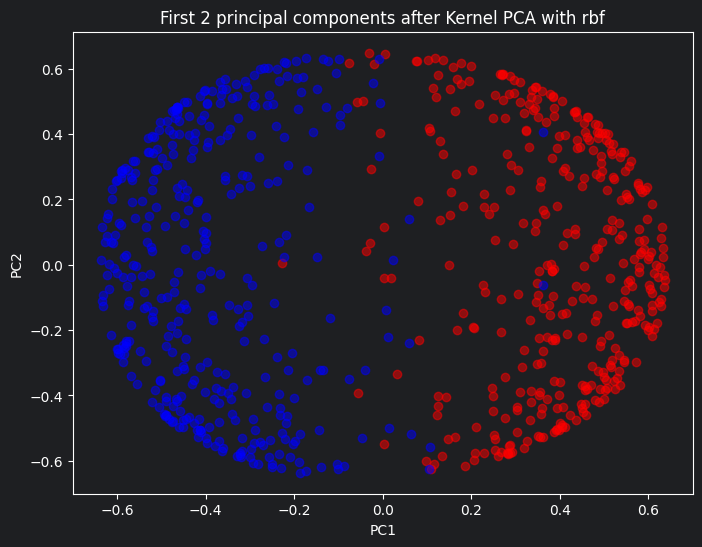

In [97]:
rbfpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.01)
X_train_rbf = rbfpca.fit_transform(X_train_b)
X_test_rbf  = rbfpca.transform(X_test_b)

plt.figure(figsize=(8,6))
plt.scatter(X_train_rbf[y_train_b==0, 0], X_train_rbf[y_train_b==0, 1], color='red', alpha=0.5)
plt.scatter(X_train_rbf[y_train_b==1, 0], X_train_rbf[y_train_b==1, 1], color='blue', alpha=0.5)

plt.title('First 2 principal components after Kernel PCA with rbf')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

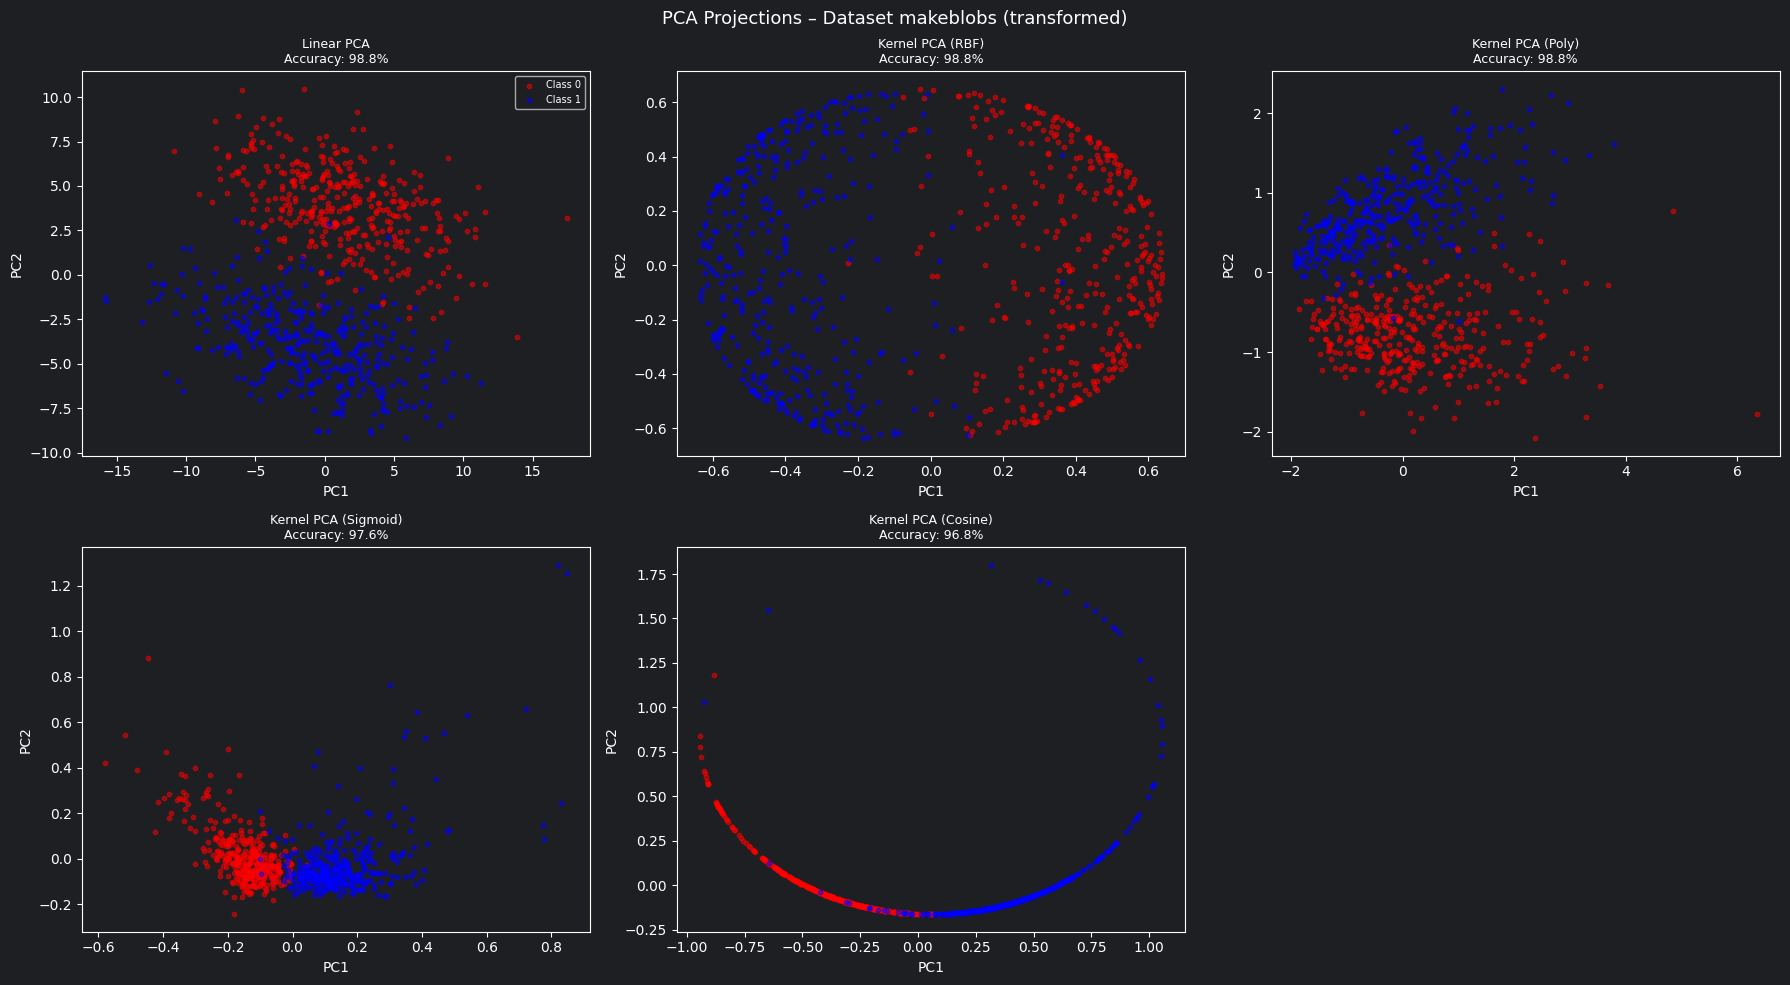

In [100]:
# ----------------------------------------------
# Plotting all PCA projections – makeblobs
# ----------------------------------------------

# Using the grid search models
pca_configs_blobs = [
    ("Linear PCA",                pca),
    ("Kernel PCA (RBF)",          rbfpca),
    ("Kernel PCA (Poly)",         polpca),
    ("Kernel PCA (Sigmoid)",      sigpca),
    ("Kernel PCA (Cosine)",       cosnpca),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
axes_flat[-1].set_visible(False)

for ax, (name, decomp) in zip(axes_flat, pca_configs_blobs):
    Xtr_proj = decomp.fit_transform(X_train_b)
    Xte_proj = decomp.transform(X_test_b)

    lr = LogisticRegression(max_iter=1000)
    lr.fit(Xtr_proj, y_train_b)
    acc = accuracy_score(y_test_b, lr.predict(Xte_proj)) * 100

    for cls in [0, 1]:
        mask = y_train_b == cls
        ax.scatter(Xtr_proj[mask, 0], Xtr_proj[mask, 1],
                   color=colors[cls], alpha=0.5, s=10, label=f"Class {cls}")

    ax.set_title(f"{name}\nAccuracy: {acc:.1f}%", fontsize=9)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

axes_flat[0].legend(fontsize=7)
plt.suptitle("PCA Projections – Dataset makeblobs (transformed)", fontsize=13)
plt.tight_layout()
plt.show()

### 3c — Discussion

*Write your observations here.*

- How does the performance of linear PCA compare to Kernel PCA on `make_blobs` vs `make_moons`?
- Which kernel worked best on each dataset, and why do you think that is?
- When would you expect linear PCA to be sufficient?

1. Performance of linear PCA vs. Kernel PCA on `make_blobs` & `make_moons`
    * Linear PCA works better in `make_blobs` due to linear random transformation to the data. When we move from two spherical clouds of data to two more "seized" clouds, the linear PCA could be the best overall. In the `make_moons` dataset the situation was different, becouse the data was not linear, so the Linear PCA struggled to separate the clouds.
2. Best kernels for each dataset
    * `make_moons`: The best kernel was the Gaussian with $\gamma=15$, scoring accuracy of 91.6%.
    * `make_blobs`: The best kernel was the Linear, scoring accuracy of 98.8% in the test Set, but in reality all kernels are equivalent becouse the worst scores 96% of accuracy.
    * Why does this result? For the `make_blobs` dataset the answare is obyusly becouse we had apply a random linear transformation, helping the Linear PCA to perform properly. We have to notice that all the kernel functions worked well, in fact, the best one on validation was the sigmoid with 97.07% accuracy, where the Linear scores 96.8%. We can infer that the all kernels are equivalent on this dataset. For the `make_moons` dataset the situation was different, in fact the Gaussian kernel succesfully separates the data, but linear and polynmoial fail (polynomial was the second-best kernel), this becouse of the complex geometry of the data. We have to notice that we had used $\gamma=15$, meaning that to capture the complexity of the data, we need a more complex model. This is why linear kernel, and the others, performances are way worse than Gaussian.
3. The linear PCA should be enough when the data points are linear-separable.
